In [ ]:
from dataclasses import dataclass
from pathlib import Path
import os
import math
from pprint import pprint

import cv2
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
import pillow_heif
pillow_heif.register_heif_opener() # Register HEIF opener to allow PIL to read HEIC files

In [2]:
Path.cwd()

WindowsPath('c:/Proyectos/KINECTRICS/Anomaly-Detection/notebooks')

In [38]:
#-------------------------------------------------------------------------------
# Paths
#-------------------------------------------------------------------------------
DATA_DIR = Path("../data_raw").resolve()
print(DATA_DIR)

#-------------------------------------------------------------------------------
# Constants
#-------------------------------------------------------------------------------
VALID_EXTS = {".jpg", ".jpeg", ".png", ".heic", ".bmp", ".tiff"}

C:\Proyectos\KINECTRICS\Anomaly-Detection\data_raw


In [4]:
@dataclass
class PreprocessConfig:
    output_size: tuple[int, int] = (512, 512)
    padding_color: tuple[int, int, int] = (235, 235, 235)
    crop_margin_ratio: float = 0.08
    canny_threshold1: int = 50
    canny_threshold2: int = 150
    morph_kernel_size: int = 9
    min_component_area_ratio: float = 0.01
    hough_threshold: int = 80
    hough_min_line_length_ratio: float = 0.15
    hough_max_line_gap: int = 20
    debug: bool = True

---
# Loading Data
---

### List all the available images in the given folder:

In [36]:
def list_files(directory: Path) -> list[Path]:
    """ Returns the list of paths of all the images in the given directory and subdirectories. """
    files = []
    for root, dirs, filenames in os.walk(directory):
        for fl in filenames:
            if Path(fl).suffix.lower() not in VALID_EXTS: # skip non-image files
                continue
            files.append(Path(root) / fl)
    files.sort()
    return files

data_images = list_files(DATA_DIR)
print(f"Found {len(data_images)} images in {DATA_DIR}.\n")
pprint(data_images[ : 5])
print()

clean_v1 = list_files(DATA_DIR / "clean_v1")
print(f"Found {len(clean_v1)} images in {DATA_DIR / 'clean_v1'}.\n")
pprint(clean_v1[ : 5])

Found 754 images in C:\Proyectos\KINECTRICS\Anomaly-Detection\data.

[WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data/clean_v1/IMG_0595.HEIC'),
 WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data/clean_v1/IMG_0596.HEIC'),
 WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data/clean_v1/IMG_0597.HEIC'),
 WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data/clean_v1/IMG_0598.HEIC'),
 WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data/clean_v1/IMG_0599.HEIC')]

Found 58 images in C:\Proyectos\KINECTRICS\Anomaly-Detection\data\clean_v1.

[WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data/clean_v1/IMG_0595.HEIC'),
 WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data/clean_v1/IMG_0596.HEIC'),
 WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data/clean_v1/IMG_0597.HEIC'),
 WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data/clean_v1/IMG_0598.HEIC'),
 WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data/clean_v1/

### Convert to a readable format for opencv:
- HEIC/HEIF: Standard OpenCV builds often lack native support for Apple's High Efficiency formats without external libraries.

<span style='color:red'> Note: </span> If `imread()` fails to read a file, it will return an **empty matrix** (None) rather than throwing an error.

In [39]:
def convert_image_format(path: Path, dataset_root: Path, ext: str) -> Path:
    """ Convert an image to a new format and save it in a sibling dataset folder, preserving its internal structure. 
    
    Example:
        dataset_root = data/
        path = data/clean_v1/set_a/img1.heic"
        ext = "jpg"

    Output:
        data_jpg/clean_v1/set_a/img1.jpg
    """
    ext = ext.lstrip(".").lower() # clean extension, e.g. "jpg" instead of ".JPG"
    dataset_root = dataset_root.resolve()
    path = path.resolve()
    
    relative_path = path.relative_to(dataset_root)                     # e.g. clean_v1/set_a/img1.heic
    output_root = dataset_root.parent / f"{dataset_root.name}_{ext}"   # e.g. data_jpg
    output_file = (output_root / relative_path).with_suffix(f".{ext}") # e.g. data_jpg/clean_v1/set_a/img1.jpg
    
    output_file.parent.mkdir(exist_ok=True, parents=True)
    
    with Image.open(path) as img: # Decodes the image using PIL, which supports HEIC format thanks to pillow_heif
        if not output_file.exists():
            img.save(output_file) # Encodes the image in the new format and saves it to the output file
        
    return output_file

In [40]:
def convert_dataset_images(dataset_root: Path, ext: str) -> list[Path]:
    """ Convert all images in a dataset to a new format and return the list of output paths. """
    input_files = list_files(dataset_root)
    output_files = []
    for path in input_files:
        try:
            output_file = convert_image_format(path, dataset_root, ext)
            output_files.append(output_file)
        except Exception as e:
            print(f"Error converting {path}: {e}")
    return output_files

In [41]:
data_jpg = convert_dataset_images(DATA_DIR, "jpg")

Error converting C:\Proyectos\KINECTRICS\Anomaly-Detection\data_raw\underwater\BundleCollage.png: Image size (425002074 pixels) exceeds limit of 178956970 pixels, could be decompression bomb DOS attack.
Error converting C:\Proyectos\KINECTRICS\Anomaly-Detection\data_raw\underwater\ElementCollage El1.png: Image size (242702234 pixels) exceeds limit of 178956970 pixels, could be decompression bomb DOS attack.


In [42]:
print(f"{len(data_jpg)} images converted from {DATA_DIR}.\n")
pprint(data_jpg[ : 5])
print()

752 images converted from C:\Proyectos\KINECTRICS\Anomaly-Detection\data_raw.

[WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data_raw_jpg/clean_v1/IMG_0595.jpg'),
 WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data_raw_jpg/clean_v1/IMG_0596.jpg'),
 WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data_raw_jpg/clean_v1/IMG_0597.jpg'),
 WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data_raw_jpg/clean_v1/IMG_0598.jpg'),
 WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data_raw_jpg/clean_v1/IMG_0599.jpg')]



---
OpenCV follows this pattern:
 - imread → needs how to read the image code `IMREAD_*`
 - cvtColor → needs color conversion code `COLOR_*`

**Flags** = Predefined CONSTANTS (numbers) to control how data is read or processed by OpenCV. Common flags include:

`img = cv2.imread(path, flag)`
- `cv2.IMREAD_COLOR`: Reads the image in color (default).
- `cv2.IMREAD_GRAYSCALE`: Reads the image in grayscale.
- `cv2.IMREAD_UNCHANGED`: Reads the image as is, including alpha channel if present.


`img_rgb = cv2.cvtColor(img, flag)`
- `cv2.COLOR_BGR2RGB`: Converts an image from BGR color space (used by OpenCV) to RGB color space (used by Matplotlib and PIL).
- `cv2.COLOR_RGB2BGR`: Converts an image from RGB color space (used by Matplotlib and PIL) to BGR color space (used by OpenCV).
- `cv2.COLOR_GRAY2BGR`: Converts a grayscale image to 3 channels (e.g., when a model expects 3 channels).

In [84]:
# Example:
cv2.COLOR_BGR2RGB

4

 Image size: (4032, 3024, 3)


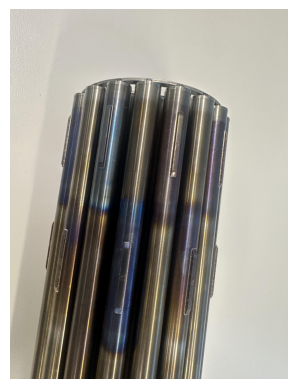

In [104]:
def load_image_rgb(image_path: Path) -> np.ndarray:
    ''' Load an image and convert it to RGB. '''
    image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    if image is None:
        raise FileNotFoundError(f"Image at {image_path} could not be loaded.")
    return image

im_path = str(data_jpg[5])
im_rgb = load_image_rgb(im_path)

print(f' Image size: {im_rgb.shape}')
plt.axis("off")
plt.imshow(im_rgb)
plt.show()

In [ ]:
def rgb_to_gray(image_rgb: np.ndarray) -> np.ndarray:
    ''' Convert an RGB image to grayscale. '''
    return cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

im_gray = rgb_to_gray(im_rgb)
print(f' Image size: {im_gray.shape}')


 Image size: (4032, 3024)
